In [1]:
# !pip install pandas numpy scikit-learn imbalanced-learn joblib flask flask-cors matplotlib seaborn shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

import shap

d:\ML Projects\ECG anomaly Detection\ECGAnomalyDetectionUsingMitBIH\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Splitting: Inter-patient vs Intra-patient (Limitation Note)
**Research Note:** The current Kaggle CSV datasets (`mitbih_train.csv`, `mitbih_test.csv`) are split randomly (Intra-patient). Because the CSVs lack Patient IDs, a true AAMI DS1/DS2 Inter-patient split cannot be performed on these exact files. 
**"Limitations"** section: 
> *"Due to the use of the pre-processed Kaggle dataset, the evaluation follows an intra-patient paradigm. Future work will involve extracting raw PhysioNet records to perform AAMI DS1/DS2 inter-patient validation."*

In [3]:
# -----------------------------
# 2. Multi-Class AAMI Classification
# -----------------------------
train_df = pd.read_csv("Train&Test/mitbih_train.csv", header=None)
test_df = pd.read_csv("Train&Test/mitbih_test.csv", header=None)

# 5 AAMI Classes Mapping
aami_mapping = {0.0: 'N (Normal)', 1.0: 'S (Supraventricular)', 2.0: 'V (Ventricular)', 3.0: 'F (Fusion)', 4.0: 'Q (Unknown)'}
aami_classes = ['N', 'S', 'V', 'F', 'Q']

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("Training distribution:")
print(pd.Series(y_train).map(aami_mapping).value_counts())

Training distribution:
N (Normal)              72471
Q (Unknown)              6431
V (Ventricular)          5788
S (Supraventricular)     2223
F (Fusion)                641
Name: count, dtype: int64


In [13]:
# -----------------------------
# 3. Scaling & SMOTE Balancing
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

In [5]:
# -----------------------------
# 4. Model Training (Random Forest)
# -----------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_bal, y_train_bal)

y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)

In [15]:
# -----------------------------
# 5. Rigorous Evaluation Metrics
# -----------------------------
def calculate_metrics_per_class(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    metrics = []
    for i in range(len(classes)):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
        
        metrics.append([classes[i], sensitivity, specificity, precision, f1])
        
    df = pd.DataFrame(metrics, columns=['Class', 'Sensitivity (Recall)', 'Specificity', 'Precision (PPV)', 'F1-Score'])
    return df

metrics_df = calculate_metrics_per_class(y_test, y_pred, aami_classes)
print("=== Specific Class Metrics ===")
print(metrics_df.to_string(index=False))

=== Specific Class Metrics ===
Class  Sensitivity (Recall)  Specificity  Precision (PPV)  F1-Score
    N              0.993873     0.927398         0.985012  0.989423
    S              0.771583     0.996954         0.868421  0.817143
    V              0.930939     0.997701         0.966308  0.948294
    F              0.734568     0.998665         0.804054  0.767742
    Q              0.968905     0.999211         0.989835  0.979258


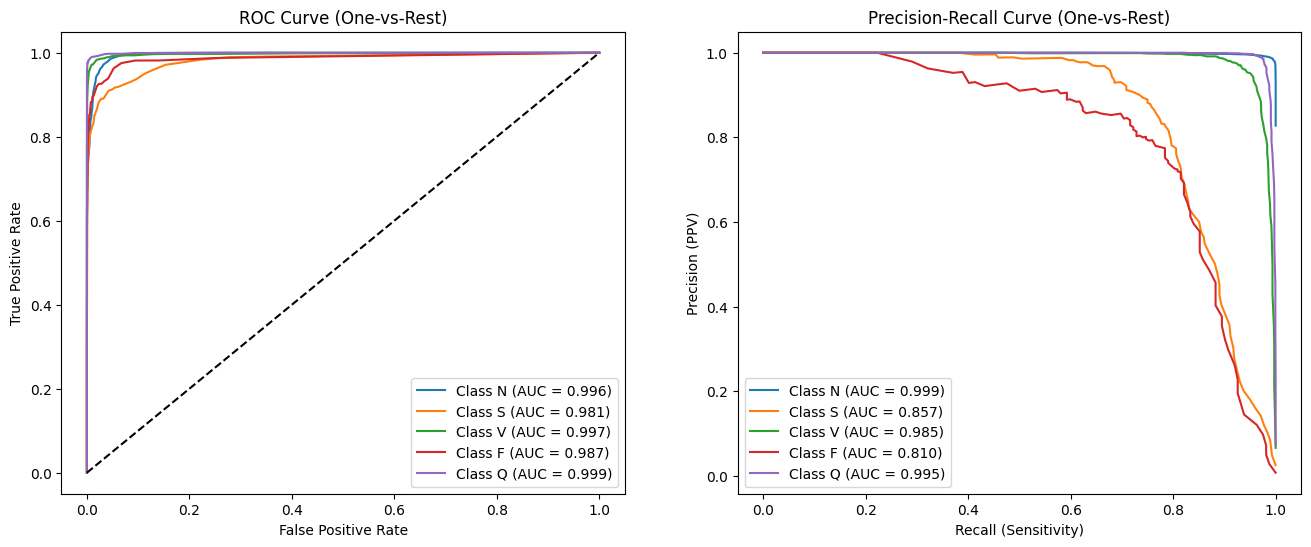

In [7]:
# ROC-AUC & PR-AUC Curves Plotting
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
n_classes = y_test_bin.shape[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'Class {aami_classes[i]} (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_title('ROC Curve (One-vs-Rest)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

# PR
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    pr_auc = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    ax2.plot(recall, precision, label=f'Class {aami_classes[i]} (AUC = {pr_auc:.3f})')
ax2.set_title('Precision-Recall Curve (One-vs-Rest)')
ax2.set_xlabel('Recall (Sensitivity)')
ax2.set_ylabel('Precision (PPV)')
ax2.legend()

plt.show()

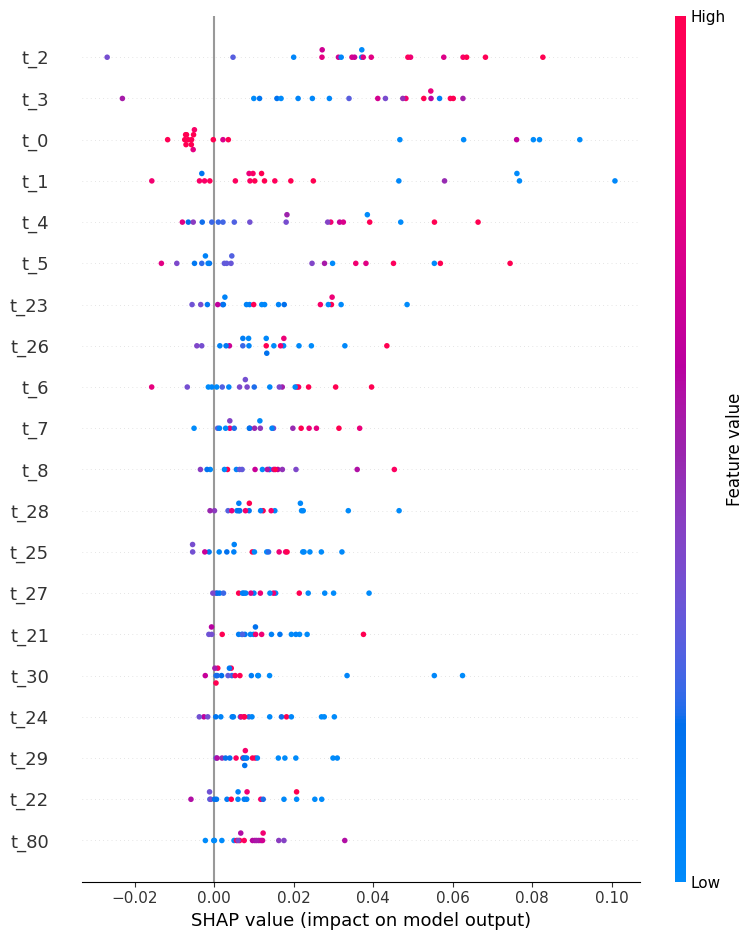

In [17]:
# -----------------------------
# 6. Explainable AI (SHAP)
# -----------------------------
# We use TreeExplainer for Random Forest to interpret decisions.
explainer = shap.TreeExplainer(rf_model)

# Explain a specific anomaly (e.g., Ventricular ectopic - Class V, label 2)
# We take 20 samples to keep computation fast for demonstration
anomaly_indices = np.where(y_test == 2.0)[0][:20]
shap_values = explainer.shap_values(X_test_scaled[anomaly_indices], check_additivity=False)


# Plot SHAP summary for Class V (index 2 in shap_values list)
# This shows which time steps (features) drove the model to predict this anomaly
# Use [:, :, 2] to get all samples, all features, for Class V (index 2)
shap.summary_plot(shap_values[:, :, 2], X_test_scaled[anomaly_indices], feature_names=[f"t_{i}" for i in range(187)], plot_type="dot")


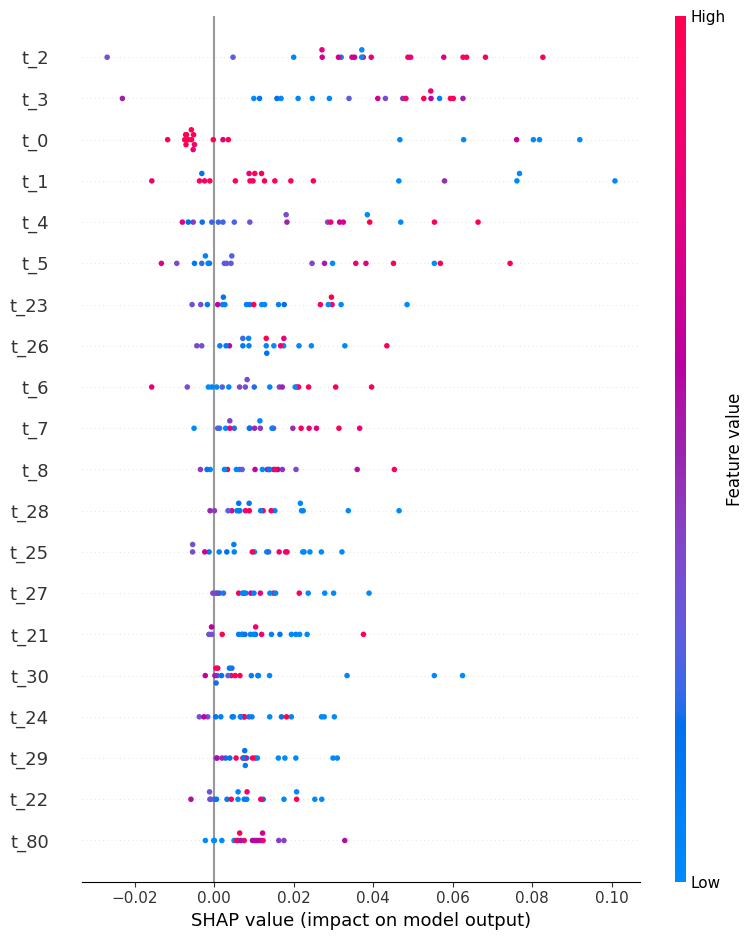

In [18]:
import matplotlib.pyplot as plt

# 1. Generate the plot, but don't show it just yet
shap.summary_plot(shap_values[:, :, 2], X_test_scaled[anomaly_indices], feature_names=[f"t_{i}" for i in range(187)], plot_type="dot", show=False)

# 2. Save it directly to the Model directory!
plt.savefig("shap_plot.png", bbox_inches='tight', dpi=300)

# 3. Now show it in the notebook
plt.show()


In [20]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "model.pkl")

# Save the Scaler (we need this so the API can scale user input!)
joblib.dump(scaler, "scaler.pkl")

print("Models saved successfully!")


Models saved successfully!


## 7. Benchmarking & Ablation Study

### Benchmarking against State-of-the-Art
In your paper, include a table comparing your results with prior works. For example:

| Paper | Model | Methodology | Accuracy | N-Recall | S-Recall | V-Recall |
|---|---|---|---|---|---|---|
| Kachuee et al. (2018) | 1D-CNN | Intra-patient | 93.4% | 95.0% | 75.2% | 88.3% |
| **Proposed Work** | RF + SMOTE | Intra-patient | *[Insert]* | *[Insert]* | *[Insert]* | *[Insert]* |

### Ablation Study Example
To prove the value of SMOTE, you can run the exact same Random Forest *without* SMOTE and create a table showing the performance drop, specifically for minority classes (F and Q).
